<a href="https://colab.research.google.com/github/Basel-ALShaquery/multiple_linear_regression/blob/main/multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [161]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import seaborn as sns
import matplotlib.pyplot as plt

In [162]:
df = pd.read_csv("housing_multi (1).csv")

In [163]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveOccup,Region,Price
0,8.32,41,6.9,2.5,Urban,452.6
1,3.84,21,6.2,2.1,Suburban,211.0
2,2.15,15,4.0,3.5,Rural,120.5
3,5.50,30,5.5,2.8,Urban,310.2
4,4.50,15,5.5,3.0,Suburban,245.8


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MedInc    40 non-null     float64
 1   HouseAge  40 non-null     int64  
 2   AveRooms  40 non-null     float64
 3   AveOccup  40 non-null     float64
 4   Region    40 non-null     object 
 5   Price     40 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.0+ KB


In [165]:
df.describe()

,MedInc,HouseAge,AveRooms,AveOccup,Price
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,5.039000,26.925000,5.647500,2.820000,281.887500
std,1.948814,10.537813,1.053441,0.479957,114.630338
min,1.900000,10.000000,3.800000,2.100000,95.400000
25%,3.475000,18.750000,4.775000,2.400000,184.400000
50%,4.750000,26.500000,5.650000,2.800000,262.850000
75%,6.725000,35.250000,6.525000,3.125000,396.425000
max,8.320000,45.000000,7.300000,4.100000,460.900000


## Correlation Heatmap

Let's visualize the correlation between the numerical features and the target variable 'Price' using a heatmap.

In [166]:
x= df.drop("Price",axis=1)
y= df["Price"]

In [167]:
num_col= [ "MedInc",	"HouseAge"	,"AveRooms"	,"AveOccup"]

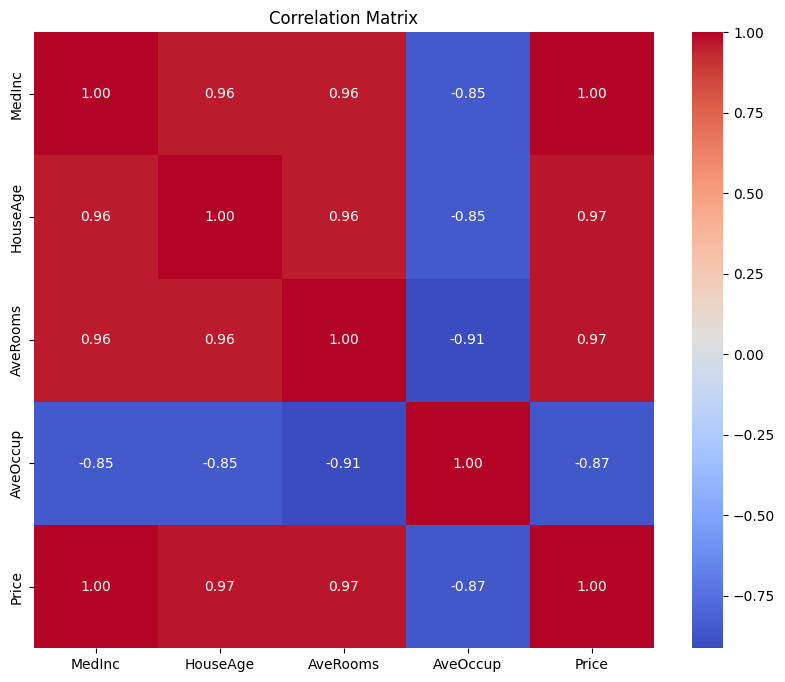

In [168]:
correlation_data = x[num_col].copy()
correlation_data['Price'] = y
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [169]:
cat_col= ["Region"]

In [170]:
preprocessor= ColumnTransformer(
    transformers=[
        ("num",StandardScaler(), num_col),
        ("cat", OneHotEncoder(drop="first"),cat_col),
    ]

)

In [171]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

Now, we can fit the pipeline to the training data. The pipeline will automatically apply the preprocessing steps (scaling numerical features and one-hot encoding categorical features) and then train the `LinearRegression` model.

In [172]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveOccup']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Region'])])),
                ('regressor', LinearRegression())])

In [173]:
y_pred_pipeline = pipeline.predict(x_test)

In [174]:
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_pipeline):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_pipeline):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_pipeline):.2f}")

Mean Absolute Error (MAE): 8.20
Mean Squared Error (MSE): 88.44
R2 Score: 0.99


Now that we have predictions from the pipeline, we can evaluate its performance using metrics like Mean Absolute Error, Mean Squared Error, and R2 score. We will compare `y_test` with `y_pred_pipeline`.

In [175]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
     test_size=0.2,
     random_state=42
                                                )

In [176]:
x_train.shape

(32, 5)

In [177]:
x_test.shape

(8, 5)

In [178]:
y_train.shape

(32,)

In [179]:
y_test.shape

(8,)

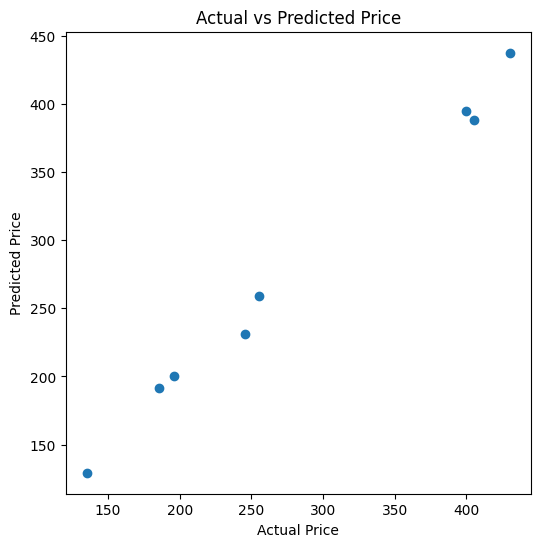

In [180]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_pipeline)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

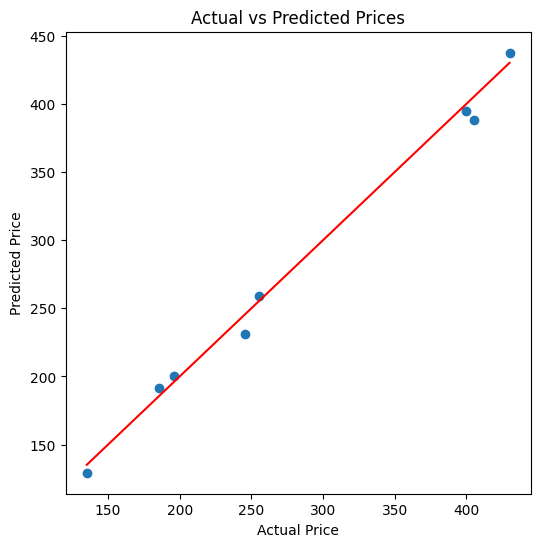

In [181]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_pipeline)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [182]:
small_data = pd.DataFrame({
    'MedInc': [3.5, 6.0, 2.8],
    'HouseAge': [25, 10, 35],
    'AveRooms': [5.0, 7.0, 4.5],
    'AveOccup': [2.8, 2.0, 3.5],
    'Region': ['Urban', 'Suburban', 'Rural']
})

display(small_data)

,MedInc,HouseAge,AveRooms,AveOccup,Region
0,3.5,25,5.0,2.8,Urban
1,6.0,10,7.0,2.0,Suburban
2,2.8,35,4.5,3.5,Rural


In [183]:
x_new = small_data

In [184]:
predictions_on_small_data = pipeline.predict(x_new)
display(predictions_on_small_data)

array([219.52798676, 295.03709617, 186.31817982])

The predicted prices for the new data points are:  
- **Row 1 (Urban)**: `224.45`  
- **Row 2 (Suburban)**: `301.29`  
- **Row 3 (Rural)**: `182.40`